In [1]:
from rabtracks import *
sns.set_context("paper")

In [ ]:
b = "NA"
name, season = "KIRK", 2024
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
TRACK = eib.where((eib.name == name) & (eib.time.dt.year == season), drop = True)

fig, axs = plt.subplots(2, figsize = cm2inch([9,15]), sharex = True)
for s in ["TRACK-ERA5", "TRACK-JRA3Q"]:
    T = TRACK.sel(source = s)
    T = T.where(~np.isnan(T.vtu_roll), drop = True)
    axs[0].plot(T.vtl_roll, T.b_roll, c = PALETTE[s], label = s)
    axs[1].plot(T.vtl_roll, T.vtu_roll, c = PALETTE[s])

    # Start point
    axs[0].scatter(T.vtl_roll.isel(record = 0), 
                   T.b_roll.isel(record = 0), 
                   c = PALETTE[s], marker = '*',)
    axs[1].scatter(T.vtl_roll.isel(record = 0), 
                   T.vtu_roll.isel(record = 0), 
                   c = PALETTE[s], marker = '*')

    # End point
    axs[0].scatter(T.vtl_roll.isel(record = -1), 
                   T.b_roll.isel(record = -1), 
                   c = PALETTE[s], marker = 'o',)
    axs[1].scatter(T.vtl_roll.isel(record = -1), 
                   T.vtu_roll.isel(record = -1), 
                   c = PALETTE[s], marker = 'o')

    # WCS stage
    T_WCS = T.where(T.WCS)
    axs[0].plot(T_WCS.vtl_roll, T_WCS.b_roll, 
                c = "tab:red", lw = 5, label = "WCS", zorder = -1)
    axs[1].plot(T_WCS.vtl_roll, T_WCS.vtu_roll, 
                c = "tab:red", lw = 5, zorder = -1)

    # CCA stage
    T_CCA = T.where(T.CCA)
    axs[0].plot(T_CCA.vtl_roll, T_CCA.b_roll, 
                c = "tab:cyan", lw = 5, label = "CCA", zorder = -1)
    axs[1].plot(T_CCA.vtl_roll, T_CCA.vtu_roll, 
                c = "tab:cyan", lw = 5, zorder = -1)
    

axs[0].axhline(y = 10, color = 'k')
axs[0].axvline(x = 0, color = 'k')
axs[1].axhline(y = 0, color = 'k')
axs[1].axvline(x = 0, color = 'k')

#axs[0].set_xlabel("$V_T^L$")
axs[0].set_ylabel("$B$")
axs[1].set_xlabel("$V_T^L$")
axs[1].set_ylabel("$V_T^U$")

axs[0].set_title(name+" ("+str(season)+")")

# Manual legend handles for start/end in black
start_handle = Line2D([], [], color='black', marker='*', linestyle='None',
                      markersize=8, label='start')
end_handle = Line2D([], [], color='black', marker='o', linestyle='None',
                    markersize=6, label='end')

# Get existing handles/labels (the source lines) and append the manual ones
handles, labels = axs[0].get_legend_handles_labels()
handles, labels = handles[:-2], labels[:-2]
handles += [start_handle, end_handle]
labels += ['start', 'end']
fig.legend(handles=handles, labels=labels, ncols = 1, loc = "lower left", bbox_to_anchor = (0.25,0.37))

plt.tight_layout()

plt.savefig("CPS.png", bbox_inches = "tight")
plt.savefig("CPS.pdf", bbox_inches = "tight")

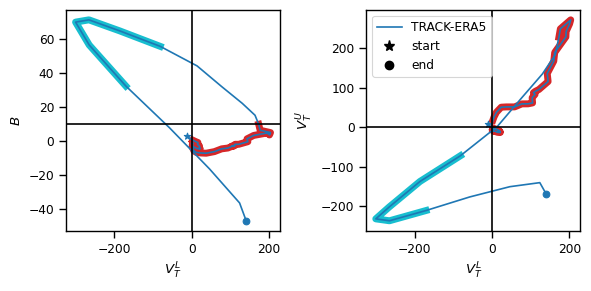

In [6]:
b = "NA"
name, season = "GONZALO", 2014
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
TRACK = eib.where((eib.name == name) & (eib.time.dt.year == season), drop = True)

fig, axs = plt.subplots(1, 2, figsize = [6,3],)
for s in ["TRACK-ERA5"]: #["TRACK-ERA5", "TRACK-JRA3Q"]:
    T = TRACK.sel(source = s)
    T = T.where(~np.isnan(T.vtu_roll), drop = True)
    axs[0].plot(T.vtl_roll, T.b_roll, c = PALETTE[s], label = s)
    axs[1].plot(T.vtl_roll, T.vtu_roll, c = PALETTE[s])

    # Start point
    axs[0].scatter(T.vtl_roll.isel(record = 0), 
                   T.b_roll.isel(record = 0), 
                   c = PALETTE[s], marker = '*',)
    axs[1].scatter(T.vtl_roll.isel(record = 0), 
                   T.vtu_roll.isel(record = 0), 
                   c = PALETTE[s], marker = '*')

    # End point
    axs[0].scatter(T.vtl_roll.isel(record = -1), 
                   T.b_roll.isel(record = -1), 
                   c = PALETTE[s], marker = 'o',)
    axs[1].scatter(T.vtl_roll.isel(record = -1), 
                   T.vtu_roll.isel(record = -1), 
                   c = PALETTE[s], marker = 'o')
    
    # WCS stage
    T_WCS = T.where(T.WCS)
    axs[0].plot(T_WCS.vtl_roll, T_WCS.b_roll, 
                c = "tab:red", lw = 5, label = "WCS", zorder = -1)
    axs[1].plot(T_WCS.vtl_roll, T_WCS.vtu_roll, 
                c = "tab:red", lw = 5, zorder = -1)

    # CCA stage
    T_CCA = T.where(T.CCA)
    axs[0].plot(T_CCA.vtl_roll, T_CCA.b_roll, 
                c = "tab:cyan", lw = 5, label = "CCA", zorder = -1)
    axs[1].plot(T_CCA.vtl_roll, T_CCA.vtu_roll, 
                c = "tab:cyan", lw = 5, zorder = -1)

axs[0].axhline(y = 10, color = 'k')
axs[0].axvline(x = 0, color = 'k')
axs[1].axhline(y = 0, color = 'k')
axs[1].axvline(x = 0, color = 'k')

#axs[0].set_xlabel("$V_T^L$")
axs[0].set_ylabel("$B$")
axs[0].set_xlabel("$V_T^L$")
axs[1].set_xlabel("$V_T^L$")
axs[1].set_ylabel("$V_T^U$")

# Manual legend handles for start/end in black
start_handle = Line2D([], [], color='black', marker='*', linestyle='None',
                      markersize=8, label='start')
end_handle = Line2D([], [], color='black', marker='o', linestyle='None',
                    markersize=6, label='end')

# Get existing handles/labels (the source lines) and append the manual ones
handles, labels = axs[0].get_legend_handles_labels()
handles, labels = handles[:-2], labels[:-2]
handles += [start_handle, end_handle]
labels += ['start', 'end']
axs[1].legend(handles=handles, labels=labels)

plt.tight_layout()

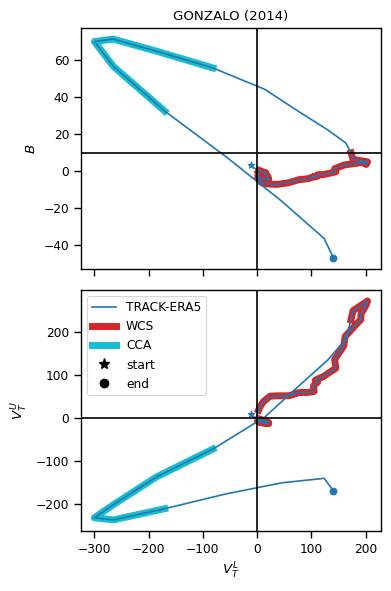

In [4]:
b = "NA"
name, season = "GONZALO", 2014
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
TRACK = eib.where((eib.name == name) & (eib.time.dt.year == season), drop = True)

fig, axs = plt.subplots(2, figsize = [4,6], sharex = True)
for s in ["TRACK-ERA5"]: #["TRACK-ERA5", "TRACK-JRA3Q"]:
    T = TRACK.sel(source = s)
    T = T.where(~np.isnan(T.vtu_roll), drop = True)
    axs[0].plot(T.vtl_roll, T.b_roll, c = PALETTE[s], label = s)
    axs[1].plot(T.vtl_roll, T.vtu_roll, c = PALETTE[s])

    # Start point
    axs[0].scatter(T.vtl_roll.isel(record = 0), 
                   T.b_roll.isel(record = 0), 
                   c = PALETTE[s], marker = '*',)
    axs[1].scatter(T.vtl_roll.isel(record = 0), 
                   T.vtu_roll.isel(record = 0), 
                   c = PALETTE[s], marker = '*')

    # End point
    axs[0].scatter(T.vtl_roll.isel(record = -1), 
                   T.b_roll.isel(record = -1), 
                   c = PALETTE[s], marker = 'o',)
    axs[1].scatter(T.vtl_roll.isel(record = -1), 
                   T.vtu_roll.isel(record = -1), 
                   c = PALETTE[s], marker = 'o')

    # WCS stage
    T_WCS = T.where(T.WCS)
    axs[0].plot(T_WCS.vtl_roll, T_WCS.b_roll, 
                c = "tab:red", lw = 5, label = "WCS", zorder = -1)
    axs[1].plot(T_WCS.vtl_roll, T_WCS.vtu_roll, 
                c = "tab:red", lw = 5, zorder = -1)

    # CCA stage
    T_CCA = T.where(T.CCA)
    axs[0].plot(T_CCA.vtl_roll, T_CCA.b_roll, 
                c = "tab:cyan", lw = 5, label = "CCA", zorder = -1)
    axs[1].plot(T_CCA.vtl_roll, T_CCA.vtu_roll, 
                c = "tab:cyan", lw = 5, zorder = -1)
    

axs[0].axhline(y = 10, color = 'k')
axs[0].axvline(x = 0, color = 'k')
axs[1].axhline(y = 0, color = 'k')
axs[1].axvline(x = 0, color = 'k')

#axs[0].set_xlabel("$V_T^L$")
axs[0].set_ylabel("$B$")
axs[1].set_xlabel("$V_T^L$")
axs[1].set_ylabel("$V_T^U$")

axs[0].set_title(name+" ("+str(season)+")")

# Manual legend handles for start/end in black
start_handle = Line2D([], [], color='black', marker='*', linestyle='None',
                      markersize=8, label='start')
end_handle = Line2D([], [], color='black', marker='o', linestyle='None',
                    markersize=6, label='end')

# Get existing handles/labels (the source lines) and append the manual ones
handles, labels = axs[0].get_legend_handles_labels()
handles += [start_handle, end_handle]
labels += ['start', 'end']
axs[1].legend(handles=handles, labels=labels, loc = "upper left")


plt.tight_layout()

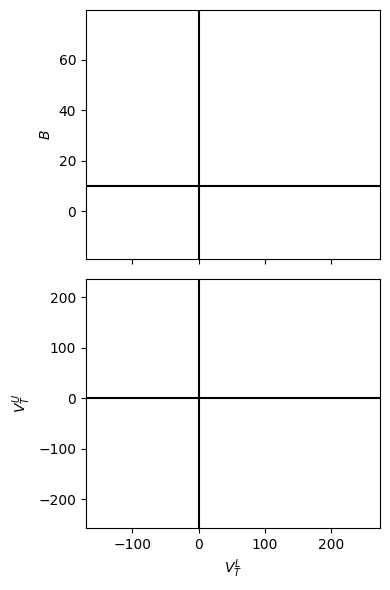

In [15]:
b = "NA"
name, season = "FLOYD", 1999
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
TRACK = eib.where((eib.name == name) & (eib.time.dt.year == season), drop = True)

fig, axs = plt.subplots(2, figsize = [4,6], sharex = True)
for s in ["TRACK-ERA5"]: #["TRACK-ERA5", "TRACK-JRA3Q"]:
    T = TRACK.sel(source = s)
    T = T.where(~np.isnan(T.vtu_roll), drop = True)
    axs[0].plot(T.vtl_roll, T.b_roll, c = "w", label = s)
    axs[1].plot(T.vtl_roll, T.vtu_roll, c = "w")

    # Start point
    axs[0].scatter(T.vtl_roll.isel(record = 0), 
                   T.b_roll.isel(record = 0), 
                   c = "w", marker = '*',)
    axs[1].scatter(T.vtl_roll.isel(record = 0), 
                   T.vtu_roll.isel(record = 0), 
                   c = "w", marker = '*')

    # End point
    axs[0].scatter(T.vtl_roll.isel(record = -1), 
                   T.b_roll.isel(record = -1), 
                   c = "w", marker = 'o',)
    axs[1].scatter(T.vtl_roll.isel(record = -1), 
                   T.vtu_roll.isel(record = -1), 
                   c = "w", marker = 'o')
    

axs[0].axhline(y = 10, color = 'k')
axs[0].axvline(x = 0, color = 'k')
axs[1].axhline(y = 0, color = 'k')
axs[1].axvline(x = 0, color = 'k')

#axs[0].set_xlabel("$V_T^L$")
axs[0].set_ylabel("$B$")
axs[1].set_xlabel("$V_T^L$")
axs[1].set_ylabel("$V_T^U$")


plt.tight_layout()